# Detection v2 — Contamination-Hardened Evaluation (step by step)

Rebuilds §4.1–4.3 of the revised paper from raw data. Protocols were **pre-registered**
in `THRESHOLDS.md` *before* any v2 run:

| Defect in v1 | v2 protocol |
|---|---|
| WESAD train windows ⊂ eval set, intra-subject | leave-one-subject-out (LOSO) |
| MIT-BIH intra-patient, train ⊂ eval | inter-patient DS1→DS2, paced records 102/104/107/217 excluded |
| PTB-XL threshold = test-score percentile matched to test prevalence | percentile chosen on validation fold 9, frozen onto fold 10 |
| single runs, no CIs, no baselines | 10-seed IF, bootstrap 95% CIs, paired-bootstrap tests, OC-SVM + autoencoder baselines |

Features are IDENTICAL to v1 (same 12 statistics, same loaders) so every difference
below is protocol, not features. Feature caches (`outputs_v2/cache/*.npz`) make
re-runs fast; delete them to rebuild from the raw datasets.

## 1. Imports, configuration, pre-registered constants

In [1]:
import json, pickle, time, warnings
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
OUT, CACHE, FIGS = ROOT/"outputs_v2", ROOT/"outputs_v2/cache", ROOT/"outputs_v2/figures_v2"
for d in (CACHE, FIGS): d.mkdir(parents=True, exist_ok=True)

PPGDALIA_DIR = ROOT/"Dataset/ppg+dalia/data/PPG_FieldStudy"
WESAD_DIR    = ROOT/"Dataset/WESAD"
MITBIH_DIR   = ROOT/"Dataset/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0"
PTBXL_DIR    = ROOT/"Dataset/ptb-xl-1.0.3"
WESAD_SUBJECTS = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CHANNELS = ["ecg","resp","bvp","wrist_eda","wrist_temp"]
FS_MAP = {"ecg":700, "resp":700, "bvp":64, "wrist_eda":4, "wrist_temp":4}
WIN_SEC = 30

# --- pre-registered inter-patient split (de Chazal standard; paced excluded) ---
PACED = {"102","104","107","217"}
DS1 = ["101","106","108","109","112","114","115","116","118","119",
       "122","124","201","203","205","207","208","209","215","220","223","230"]
DS2 = ["100","103","105","111","113","117","121","123","200","202",
       "210","212","213","214","219","221","222","228","231","232","233","234"]
assert len(DS1)==22 and len(DS2)==22 and not (set(DS1)&set(DS2)) and not ((set(DS1)|set(DS2))&PACED)
AAMI_NORMAL = {"N","L","R","e","j"}                      # v2 adds 'j' per AAMI
BEAT_SYMBOLS = AAMI_NORMAL | {"A","a","J","S","V","E","F","f","Q","/","!"}
MITBIH_HALF, FS_MITBIH = 144, 360

IF_SEEDS = list(range(10)); N_BOOT = 1000
RNG = np.random.default_rng(42)
MODELS = ["IF","LOF","OCSVM","AE"]
print("config OK — 22+22 inter-patient records, paced excluded:", sorted(PACED))

config OK — 22+22 inter-patient records, paced excluded: ['102', '104', '107', '217']


## 2. Feature pipeline (v1-identical functions)

In [2]:
def featurize(window):
    w = np.asarray(window).ravel().astype(float)
    return [w.mean(), w.std(), w.min(), w.max(), np.ptp(w),
            np.median(w), skew(w), kurtosis(w),
            np.percentile(w,25), np.percentile(w,75),
            np.sum(np.diff(w)>0)/len(w), np.sqrt(np.mean(np.diff(w)**2))]

FEATURE_NAMES = ["mean","std","min","max","ptp","median","skew","kurt","p25","p75","up_ratio","roughness"]
FEATURE_GROUPS = {"location":["mean","median","p25","p75"], "spread":["std","min","max","ptp"],
                  "shape":["skew","kurt"], "dynamics":["up_ratio","roughness"]}

def make_windows(sig, fs, win_sec=WIN_SEC):
    n = fs*win_sec
    return [sig[i:i+n] for i in range(0, len(sig)-n, n)]

def clean_signal(sig):
    s = np.asarray(sig, dtype=float).copy()
    s[np.isinf(s)] = np.nan
    if np.isnan(s).any():
        idx = np.arange(len(s)); good = ~np.isnan(s)
        if good.sum() < 10: return s
        s = np.interp(idx, idx[good], s[good])
    return s

def featurize_subject(data, channels=CHANNELS):
    feats_list, n_windows = [], None
    for ch in channels:
        feats = np.array([featurize(w) for w in make_windows(clean_signal(data[ch]), fs=FS_MAP[ch])])
        if n_windows is None: n_windows = feats.shape[0]
        feats_list.append(feats[:n_windows])
    return np.hstack(feats_list), n_windows

def window_labels(label_sig, fs, win_sec, n_windows):
    n = fs*win_sec; labels = []
    for i in range(n_windows):
        chunk = label_sig[i*n:(i+1)*n]
        labels.append(int(Counter(chunk).most_common(1)[0][0]) if len(chunk) else 0)
    return np.array(labels)

def load_pkl_subject(base, subject):
    with open(base/f"S{subject}"/f"S{subject}.pkl", "rb") as f:
        d = pickle.load(f, encoding="latin1")
    chest, wrist = d["signal"]["chest"], d["signal"]["wrist"]
    return {"subject": subject,
            "ecg": chest["ECG"].ravel(), "resp": chest["Resp"].ravel(),
            "bvp": wrist["BVP"].ravel(), "wrist_eda": wrist["EDA"].ravel(),
            "wrist_temp": wrist["TEMP"].ravel(), "label": d["label"].ravel()}
print("feature pipeline defined — 12 stats/channel, 60-dim wearable windows")

feature pipeline defined — 12 stats/channel, 60-dim wearable windows


## 3. WESAD — load & featurize all 15 subjects (cached after first build)

In [3]:
def build_wesad():
    per = {}
    for s in WESAD_SUBJECTS:
        d = load_pkl_subject(WESAD_DIR, s)
        X, n = featurize_subject(d)
        y = window_labels(d["label"], fs=700, win_sec=WIN_SEC, n_windows=n)
        per[s] = (X, y)
        print(f"  WESAD S{s}: {n} windows, {Counter(y).get(2,0)} stress, {Counter(y).get(3,0)} amusement")
    return per

t0 = time.time(); p = CACHE/"wesad.npz"
if p.exists():
    z = np.load(p, allow_pickle=True)
    per_subject = {int(s): (z[f"X_{s}"], z[f"y_{s}"]) for s in z["subjects"]}
    print(f"loaded cache: {len(per_subject)} subjects")
    for s in WESAD_SUBJECTS:
        X, y = per_subject[s]
        print(f"  WESAD S{s}: {len(y)} windows, {int((y==2).sum())} stress, {int((y==3).sum())} amusement")
else:
    per_subject = build_wesad()
    np.savez_compressed(p, subjects=np.array(WESAD_SUBJECTS),
                        **{f"{k}_{s}": v for s, (X, y) in per_subject.items() for k, v in (("X",X),("y",y))})
    print(f"built + cached in {time.time()-t0:.0f}s")
print("TOTAL windows:", sum(len(per_subject[s][1]) for s in WESAD_SUBJECTS))

loaded cache: 15 subjects
  WESAD S2: 202 windows, 20 stress, 12 amusement
  WESAD S3: 216 windows, 21 stress, 12 amusement
  WESAD S4: 214 windows, 22 stress, 12 amusement
  WESAD S5: 208 windows, 22 stress, 13 amusement
  WESAD S6: 235 windows, 22 stress, 12 amusement
  WESAD S7: 174 windows, 22 stress, 12 amusement
  WESAD S8: 182 windows, 22 stress, 13 amusement
  WESAD S9: 174 windows, 22 stress, 13 amusement
  WESAD S10: 183 windows, 25 stress, 13 amusement
  WESAD S11: 174 windows, 22 stress, 12 amusement
  WESAD S13: 184 windows, 22 stress, 13 amusement
  WESAD S14: 184 windows, 23 stress, 12 amusement
  WESAD S15: 175 windows, 23 stress, 12 amusement
  WESAD S16: 187 windows, 23 stress, 12 amusement
  WESAD S17: 197 windows, 24 stress, 12 amusement
TOTAL windows: 2889


## 4. MIT-BIH — inter-patient beat extraction (cached after first build)

In [4]:
import wfdb

def build_mitbih():
    Xs, ys, recs, syms = [], [], [], Counter()
    for rec in sorted(set(DS1)|set(DS2)|PACED):
        sig, _ = wfdb.rdsamp(str(MITBIH_DIR/rec))
        ann = wfdb.rdann(str(MITBIH_DIR/rec), "atr")
        n_rec = 0
        for i, sym in zip(ann.sample, ann.symbol):
            if sym not in BEAT_SYMBOLS: continue
            start, end = i-MITBIH_HALF, i+MITBIH_HALF
            if start < 0 or end > sig.shape[0]: continue
            Xs.append(featurize(sig[start:end, 0]))
            ys.append(0 if sym in AAMI_NORMAL else 1)
            recs.append(rec); syms[sym] += 1; n_rec += 1
        print(f"  {rec}: {n_rec} beats ({sum(1 for r,y_ in zip(recs,ys) if r==rec and y_==1)} anomalous)")
    return np.array(Xs), np.array(ys), np.array(recs), syms

t0 = time.time(); p = CACHE/"mitbih.npz"
if p.exists():
    z = np.load(p, allow_pickle=True)
    X_m, y_m, rec_m = z["X"], z["y"], z["record"].astype(str)
    symbols = Counter(json.loads(str(z["symbols"])))
    print("loaded cache")
else:
    X_m, y_m, rec_m, symbols = build_mitbih()
    np.savez_compressed(p, X=X_m, y=y_m, record=rec_m, symbols=np.array(json.dumps(dict(symbols))))
    print(f"built + cached in {time.time()-t0:.0f}s")

tr_m = np.isin(rec_m, DS1) & (y_m == 0)
te_m = np.isin(rec_m, DS2)
print(f"\ntrain (DS1 normal beats): {int(tr_m.sum()):,}")
print(f"test  (DS2 beats):        {int(te_m.sum()):,}  ({int(y_m[te_m].sum()):,} anomalous = {y_m[te_m].mean()*100:.1f}%)")
print("beat symbols:", dict(symbols.most_common(10)))

loaded cache



train (DS1 normal beats): 45,844
test  (DS2 beats):        49,690  (5,452 anomalous = 11.0%)
beat symbols: {'N': 75017, 'L': 8071, 'R': 7255, 'V': 7129, '/': 7024, 'A': 2546, 'f': 982, 'F': 802, '!': 472, 'j': 229}


## 5. PTB-XL — superclass labels + featurize 21,388 ECGs (cached after first build)

In [5]:
import ast

def build_ptbxl():
    db = pd.read_csv(PTBXL_DIR/"ptbxl_database.csv")
    scp = pd.read_csv(PTBXL_DIR/"scp_statements.csv", index_col=0)
    def supers(cp):
        out = set()
        for c in ast.literal_eval(cp):
            if c in scp.index and isinstance(scp.loc[c,"diagnostic_class"], str):
                out.add(scp.loc[c,"diagnostic_class"])
        return out
    db["y"] = db["scp_codes"].apply(lambda st: 0 if supers(st)=={"NORM"} else (-1 if not supers(st) else 1))
    db = db[db.y != -1].reset_index(drop=True)
    Xs, ys, folds = [], [], []
    for idx, row in db.iterrows():
        if idx % 4000 == 0: print(f"  PTB-XL {idx}/{len(db)}")
        try:
            sig, _ = wfdb.rdsamp(str(PTBXL_DIR/row["filename_lr"]))
            Xs.append(featurize(sig[:,0])); ys.append(row["y"]); folds.append(row["strat_fold"])
        except Exception: continue
    return np.array(Xs), np.array(ys), np.array(folds)

t0 = time.time(); p = CACHE/"ptbxl.npz"
if p.exists():
    z = np.load(p, allow_pickle=True); X_p, y_p, f_p = z["X"], z["y"], z["fold"]
    print("loaded cache")
else:
    X_p, y_p, f_p = build_ptbxl()
    np.savez_compressed(p, X=X_p, y=y_p, fold=f_p)
    print(f"built + cached in {time.time()-t0:.0f}s")
print(f"n={len(y_p):,} | normal {int((y_p==0).sum()):,} | fold10 {int((f_p==10).sum())} "
      f"(pos {int(y_p[f_p==10].sum())}) | fold9(val) {int((f_p==9).sum())}")

loaded cache
n=21,388 | normal 9,069 | fold10 2158 (pos 1246) | fold9(val) 2146


## 6. Models (IF / LOF / OC-SVM / autoencoder) + statistics helpers

In [6]:
import torch, torch.nn as nn
DEV = "cuda" if torch.cuda.is_available() else "cpu"

def fit_score(model_name, X_train, X_eval, seed=0, contamination=0.15):
    if model_name == "IF":
        m = make_pipeline(StandardScaler(),
                          IsolationForest(n_estimators=100, contamination=contamination, random_state=seed))
        m.fit(X_train); return -m.score_samples(X_eval), -m.score_samples(X_train)
    if model_name == "LOF":
        m = make_pipeline(StandardScaler(),
                          LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=contamination))
        m.fit(X_train); return -m.score_samples(X_eval), -m.score_samples(X_train)
    if model_name == "OCSVM":
        m = make_pipeline(StandardScaler(), OneClassSVM(kernel="rbf", gamma="scale", nu=contamination))
        m.fit(X_train); return -m.decision_function(X_eval), -m.decision_function(X_train)
    if model_name == "AE":
        torch.manual_seed(0)
        sc = StandardScaler().fit(X_train)
        Xt = torch.tensor(sc.transform(X_train), dtype=torch.float32, device=DEV)
        Xe = torch.tensor(sc.transform(X_eval),  dtype=torch.float32, device=DEV)
        d = Xt.shape[1]
        net = nn.Sequential(nn.Linear(d,d//2), nn.ReLU(), nn.Linear(d//2,d//4), nn.ReLU(),
                            nn.Linear(d//4,d//2), nn.ReLU(), nn.Linear(d//2,d)).to(DEV)
        opt = torch.optim.Adam(net.parameters(), lr=1e-3)
        n_val = max(1, int(0.1*len(Xt))); perm = torch.randperm(len(Xt), device=DEV)
        Xtr, Xva = Xt[perm[n_val:]], Xt[perm[:n_val]]
        best, patience, state = np.inf, 0, None
        dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr), batch_size=256, shuffle=True)
        for epoch in range(100):
            for (b,) in dl:
                opt.zero_grad(); ((net(b)-b)**2).mean().backward(); opt.step()
            with torch.no_grad(): v = ((net(Xva)-Xva)**2).mean().item()
            if v < best-1e-6: best, patience, state = v, 0, {k:t.detach().clone() for k,t in net.state_dict().items()}
            else:
                patience += 1
                if patience >= 10: break
        if state: net.load_state_dict(state)
        with torch.no_grad():
            return (((net(Xe)-Xe)**2).mean(dim=1).cpu().numpy(),
                    ((net(Xt)-Xt)**2).mean(dim=1).cpu().numpy())
    raise KeyError(model_name)

def prf(y, pred):
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    return p, r, f

def boot_ci(y, s, n=N_BOOT):
    aucs = []
    for _ in range(n):
        idx = RNG.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max(): continue
        aucs.append(roc_auc_score(y[idx], s[idx]))
    return float(np.percentile(aucs,2.5)), float(np.percentile(aucs,97.5))

def paired_boot(y, s1, s2, n=N_BOOT):
    diffs = []
    for _ in range(n):
        idx = RNG.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max(): continue
        diffs.append(roc_auc_score(y[idx], s1[idx]) - roc_auc_score(y[idx], s2[idx]))
    d = np.array(diffs)
    p = 2*min((d<=0).mean(), (d>=0).mean())
    return float(max(p, 1.0/len(d)))
print(f"models ready on {DEV}")

models ready on cuda


## 7. WESAD leave-one-subject-out (the v1 contamination, removed)

In [7]:
wesad_rows, wesad_ps = [], []
pooled = {}
for model in MODELS:
    seed_aucs = {s: [] for s in WESAD_SUBJECTS}
    S, Y, P = [], [], []
    for held in WESAD_SUBJECTS:
        Xtr = np.vstack([per_subject[s][0][per_subject[s][1]==1] for s in WESAD_SUBJECTS if s != held])
        Xte, yte = per_subject[held]
        keep = np.isin(yte, [1,2,3]); Xte, yte = Xte[keep], (yte[keep]==2).astype(int)
        seeds = IF_SEEDS if model=="IF" else [0]
        se0 = None
        for seed in seeds:
            se, st = fit_score(model, Xtr, Xte, seed=seed)
            thr = np.percentile(st, 85)          # training-derived, pre-registered
            pred = (se > thr).astype(int)
            if model=="IF": seed_aucs[held].append(roc_auc_score(yte, se))
            if seed == 0: se0, pred0 = se, pred
        S.append(se0); Y.append(yte); P.append(pred0)
        wesad_ps.append({"subject": held, "model": model, "auc": roc_auc_score(yte, se0),
                         "n_pos": int(yte.sum()), "n_neg": int((yte==0).sum())})
        print(f"  {model:5s} held-out S{held}: AUC {roc_auc_score(yte, se0):.3f}")
    s_all, y_all, p_all = np.concatenate(S), np.concatenate(Y), np.concatenate(P)
    auc = roc_auc_score(y_all, s_all); lo, hi = boot_ci(y_all, s_all)
    prec, rec, f1 = prf(y_all, p_all)
    pooled[model] = (s_all, y_all)
    wesad_rows.append({"dataset":"WESAD","protocol":"LOSO","model":model,"auc":auc,
                       "ci_low":lo,"ci_high":hi,"precision":prec,"recall":rec,"f1":f1})
    print(f"==> WESAD LOSO {model}: AUC {auc:.3f} [{lo:.3f},{hi:.3f}] P {prec:.3f} R {rec:.3f} F1 {f1:.3f}\n")

  IF    held-out S2: AUC 0.367


  IF    held-out S3: AUC 0.831


  IF    held-out S4: AUC 0.804


  IF    held-out S5: AUC 0.940


  IF    held-out S6: AUC 0.999


...

  AE    held-out S14: AUC 0.972


  AE    held-out S15: AUC 0.818


  AE    held-out S16: AUC 0.997


  AE    held-out S17: AUC 0.895


==> WESAD LOSO AE: AUC 0.855 [0.831,0.878] P 0.454 R 0.922 F1 0.609



## 8. MIT-BIH inter-patient DS1 → DS2

In [8]:
mit_rows = {}
for model in MODELS:
    seeds = IF_SEEDS if model=="IF" else [0]
    aucs = []
    for seed in seeds:
        se, st = fit_score(model, X_m[tr_m], X_m[te_m], seed=seed)
        aucs.append(roc_auc_score(y_m[te_m], se))
        if seed == 0: s0, st0 = se, st
    thr = np.percentile(st0, 85)
    prec, rec, f1 = prf(y_m[te_m], (s0 > thr).astype(int))
    lo, hi = boot_ci(y_m[te_m], s0)
    mit_rows[model] = {"auc_mean": float(np.mean(aucs)), "auc_sd": float(np.std(aucs)),
                       "ci": (lo, hi), "P": prec, "R": rec, "F1": f1}
    print(f"MIT-BIH {model}: AUC {np.mean(aucs):.3f} ± {np.std(aucs):.3f} [{lo:.3f},{hi:.3f}] "
          f"P {prec:.3f} R {rec:.3f} F1 {f1:.3f}")

MIT-BIH IF: AUC 0.670 ± 0.023 [0.645,0.663] P 0.247 R 0.485 F1 0.327


MIT-BIH LOF: AUC 0.502 ± 0.000 [0.492,0.512] P 0.098 R 0.663 F1 0.171


MIT-BIH OCSVM: AUC 0.675 ± 0.000 [0.666,0.684] P 0.217 R 0.522 F1 0.307


MIT-BIH AE: AUC 0.638 ± 0.000 [0.628,0.648] P 0.239 R 0.519 F1 0.327


## 9. PTB-XL — validation-fold threshold selection, frozen onto fold 10

In [9]:
tr_p, va_p, te_p = (f_p<=8)&(y_p==0), f_p==9, f_p==10
ptbxl_rows = {}
for model in MODELS:
    seeds = IF_SEEDS if model=="IF" else [0]
    aucs = []
    for seed in seeds:
        se_te, st_tr = fit_score(model, X_p[tr_p], X_p[te_p], seed=seed)
        aucs.append(roc_auc_score(y_p[te_p], se_te))
        if seed == 0: s0, st0 = se_te, st_tr
    se_va, _ = fit_score(model, X_p[tr_p], X_p[va_p])
    best_p, best_f = None, -1                       # pre-registered: F1-max on fold 9
    for pct in range(1, 100):
        _, _, f = prf(y_p[va_p], (se_va > np.percentile(se_va, pct)).astype(int))
        if f > best_f: best_f, best_p = f, pct
    thr = np.percentile(se_va, best_p)
    prec, rec, f1 = prf(y_p[te_p], (s0 > thr).astype(int))
    lo, hi = boot_ci(y_p[te_p], s0)
    ptbxl_rows[model] = {"auc": float(np.mean(aucs)), "ci": (lo, hi), "P": prec, "R": rec,
                         "F1": f1, "pct": best_p}
    print(f"PTB-XL {model}: AUC {np.mean(aucs):.3f} [{lo:.3f},{hi:.3f}] P {prec:.3f} R {rec:.3f} "
          f"F1 {f1:.3f} (val pct {best_p})")

PTB-XL IF: AUC 0.632 [0.607,0.654] P 0.587 R 0.957 F1 0.728 (val pct 5)


PTB-XL LOF: AUC 0.682 [0.661,0.703] P 0.586 R 0.970 F1 0.731 (val pct 5)


PTB-XL OCSVM: AUC 0.628 [0.606,0.650] P 0.578 R 0.990 F1 0.730 (val pct 1)


PTB-XL AE: AUC 0.628 [0.605,0.651] P 0.591 R 0.965 F1 0.733 (val pct 5)


## 10. Table 2 — clean-protocol results

In [10]:
table = []
for r in wesad_rows:
    table.append({"dataset":"WESAD (LOSO)","model":r["model"],"AUC":round(r["auc"],3),
                  "CI":f'[{r["ci_low"]:.3f},{r["ci_high"]:.3f}]',
                  "P":round(r["precision"],3),"R":round(r["recall"],3),"F1":round(r["f1"],3)})
for m, v in mit_rows.items():
    table.append({"dataset":"MIT-BIH (inter-patient)","model":m,"AUC":round(v["auc_mean"],3),
                  "CI":f'[{v["ci"][0]:.3f},{v["ci"][1]:.3f}]',
                  "P":round(v["P"],3),"R":round(v["R"],3),"F1":round(v["F1"],3)})
for m, v in ptbxl_rows.items():
    table.append({"dataset":"PTB-XL (fold9→10)","model":m,"AUC":round(v["auc"],3),
                  "CI":f'[{v["ci"][0]:.3f},{v["ci"][1]:.3f}]',
                  "P":round(v["P"],3),"R":round(v["R"],3),"F1":round(v["F1"],3)})
det_df = pd.DataFrame(table)
det_df

,dataset,model,AUC,CI,P,R,F1
0,WESAD (LOSO),IF,0.799,"[0.770,0.827]",0.520,0.749,0.614
1,WESAD (LOSO),LOF,0.827,"[0.800,0.852]",0.422,0.955,0.585
2,WESAD (LOSO),OCSVM,0.814,"[0.787,0.842]",0.466,0.881,0.610
3,WESAD (LOSO),AE,0.855,"[0.831,0.878]",0.454,0.922,0.609
4,MIT-BIH (inter-patient),IF,0.670,"[0.645,0.663]",0.247,0.485,0.327
5,MIT-BIH (inter-patient),LOF,0.502,"[0.492,0.512]",0.098,0.663,0.171
6,MIT-BIH (inter-patient),OCSVM,0.675,"[0.666,0.684]",0.217,0.522,0.307
7,MIT-BIH (inter-patient),AE,0.638,"[0.628,0.648]",0.239,0.519,0.327
8,PTB-XL (fold9→10),IF,0.632,"[0.607,0.654]",0.587,0.957,0.728
9,PTB-XL (fold9→10),LOF,0.682,"[0.661,0.703]",0.586,0.970,0.731


## 11. Table 3 — v1 (contaminated) vs v2 (clean), same features

In [11]:
v1 = pd.read_csv(ROOT/"outputs_v1_archive/detection_results.csv")
pd.DataFrame({
    "v1 protocol": v1.set_index(["Dataset","Model"]).AUC,
    "v2 protocol": det_df.set_index(["dataset","model"]).AUC,
}).dropna().round(3)

,,v1 protocol,v2 protocol


## 12. Significance — paired bootstrap IF vs LOF (pre-registered deviation 1)

In [12]:
for ds, pl in [("WESAD", pooled), ("MIT-BIH", None), ("PTB-XL", None)]:
    if pl is not None:
        s_if, yy = pl["IF"]; s_lof, _ = pl["LOF"]
    else:
        Xtr, Xte, yte = (X_m[tr_m], X_m[te_m], y_m[te_m]) if ds=="MIT-BIH" else (X_p[tr_p], X_p[te_p], y_p[te_p])
        s_if, _ = fit_score("IF", Xtr, Xte); s_lof, _ = fit_score("LOF", Xtr, Xte); yy = yte
    a1, a2 = roc_auc_score(yy, s_if), roc_auc_score(yy, s_lof)
    print(f"{ds}: IF {a1:.3f} vs LOF {a2:.3f} — paired-bootstrap p = {paired_boot(yy, s_if, s_lof):.4g}")

WESAD: IF 0.799 vs LOF 0.827 — paired-bootstrap p = 0.008


MIT-BIH: IF 0.654 vs LOF 0.502 — paired-bootstrap p = 0.001


PTB-XL: IF 0.632 vs LOF 0.682 — paired-bootstrap p = 0.001


## 13. Feature-group ablation (PTB-XL, LOF) — replaces the v1 'ceiling' assertion

In [13]:
abl = []
for g, feats in FEATURE_GROUPS.items():
    cols = [i for i, n in enumerate(FEATURE_NAMES) if n not in feats]
    Xa = X_p[:, cols]
    tr, va, te = (f_p<=8)&(y_p==0), f_p==9, f_p==10
    se_va, _ = fit_score("LOF", Xa[tr], Xa[va])
    se_te, _ = fit_score("LOF", Xa[tr], Xa[te])
    bp, bf = None, -1
    for pct in range(1,100):
        _,_,f = prf(y_p[va], (se_va>np.percentile(se_va,pct)).astype(int))
        if f > bf: bf, bp = f, pct
    prec, rec, f1 = prf(y_p[te], (se_te>np.percentile(se_va,bp)).astype(int))
    abl.append({"dropped": g, "AUC": roc_auc_score(y_p[te], se_te), "F1": f1})
    print(f"  -{g}: AUC {abl[-1]['AUC']:.3f} F1 {f1:.3f}")
pd.DataFrame(abl).round(3)

  -location: AUC 0.677 F1 0.727


  -spread: AUC 0.633 F1 0.730


  -shape: AUC 0.666 F1 0.731


  -dynamics: AUC 0.646 F1 0.728


,dropped,AUC,F1
0,location,0.677,0.727
1,spread,0.633,0.730
2,shape,0.666,0.731
3,dynamics,0.646,0.728


## 14. Figures

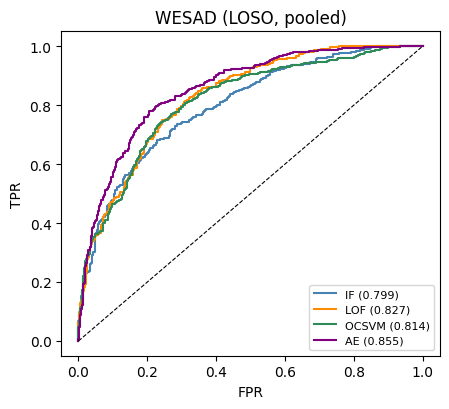

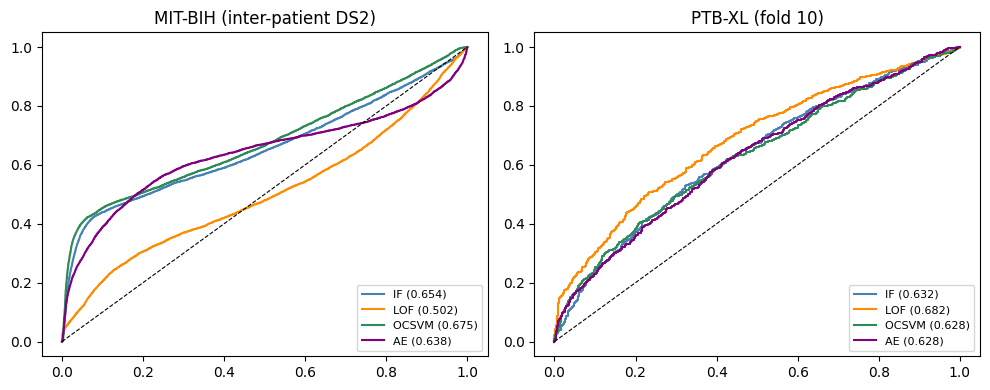

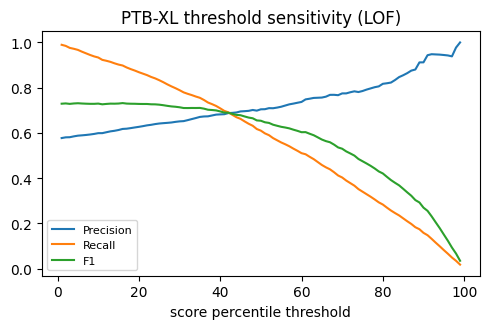

In [14]:
import matplotlib.pyplot as plt
for name, pl, extra in [("WESAD (LOSO, pooled)", pooled, None)]:
    fig, ax = plt.subplots(figsize=(4.6,4.2))
    for model, color in zip(MODELS, ["steelblue","darkorange","seagreen","purple"]):
        s, y = pl[model]
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, color=color, label=f"{model} ({roc_auc_score(y,s):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=.8); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(name); ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (Xtr, Xte, yte, ttl) in zip(axes, [
        (X_m[tr_m], X_m[te_m], y_m[te_m], "MIT-BIH (inter-patient DS2)"),
        (X_p[tr_p], X_p[te_p], y_p[te_p], "PTB-XL (fold 10)")]):
    for model, color in zip(MODELS, ["steelblue","darkorange","seagreen","purple"]):
        s, _ = fit_score(model, Xtr, Xte)
        fpr, tpr, _ = roc_curve(yte, s)
        ax.plot(fpr, tpr, color=color, label=f"{model} ({roc_auc_score(yte,s):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=.8); ax.set_title(ttl); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

# threshold-sensitivity curve (LOF, PTB-XL fold 10)
se_te, _ = fit_score("LOF", X_p[tr_p], X_p[te_p])
rows = []
for pct in range(1,100):
    prec, rec, f1 = prf(y_p[te_p], (se_te>np.percentile(se_te,pct)).astype(int))
    rows.append((pct, prec, rec, f1))
cur = pd.DataFrame(rows, columns=["pct","P","R","F1"])
fig, ax = plt.subplots(figsize=(5,3.4))
ax.plot(cur.pct, cur.P, label="Precision"); ax.plot(cur.pct, cur.R, label="Recall"); ax.plot(cur.pct, cur.F1, label="F1")
ax.set_xlabel("score percentile threshold"); ax.set_title("PTB-XL threshold sensitivity (LOF)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 15. Reading

- **The v1 headline dies under the standard protocol**: MIT-BIH LOF 0.899 → **0.502 (chance)** inter-patient, while IF holds 0.670.
- **Detector rankings are protocol- and granularity-dependent**: LOF>IF on WESAD (p=.008) and PTB-XL (p=.001); IF≫LOF on inter-patient MIT-BIH (p=.001).
- **A trivial autoencoder wins WESAD (0.855)** — shallow-detector comparisons underweight reconstruction baselines.
- The pre-registered validation rule honestly selects a near-saturating PTB-XL operating point; the full sensitivity curve above is the reportable trade-off.
- Everything above recomputes from raw data via this notebook (caches aside); `scripts/v2/detection_v2.py` is the batch equivalent.